## import

In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2

# use new data

In [4]:
modelname = 'vary p1 v5 small v2'
iepoch=12

plist = [np.array([.5, .8]),np.array([.51, .8]),np.array([.52, .8]),np.array([.53, .8])]
epoch_size = 33333
n_epoch = 66
n_seed = 1
seed = 1
no_episodes = 666  # for eval plot during training
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
node=25
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
minlen, maxlen=50,100

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch12, p[0.5 0.8]: yctore/seed1_vary p1 v5 small v2_p0_ep12 laoded
epoch12, p[0.51 0.8 ]: yctore/seed1_vary p1 v5 small v2_p1_ep12 laoded
epoch12, p[0.52 0.8 ]: yctore/seed1_vary p1 v5 small v2_p2_ep12 laoded
epoch12, p[0.53 0.8 ]: yctore/seed1_vary p1 v5 small v2_p3_ep12 laoded


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrap

123 0 0
146 0 1
122 0 2
131 0 3


/Users/yc/repo/auditory-foraging-IRC/ult.py:1046: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1046: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1046: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_99066/2185044810.py:153: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


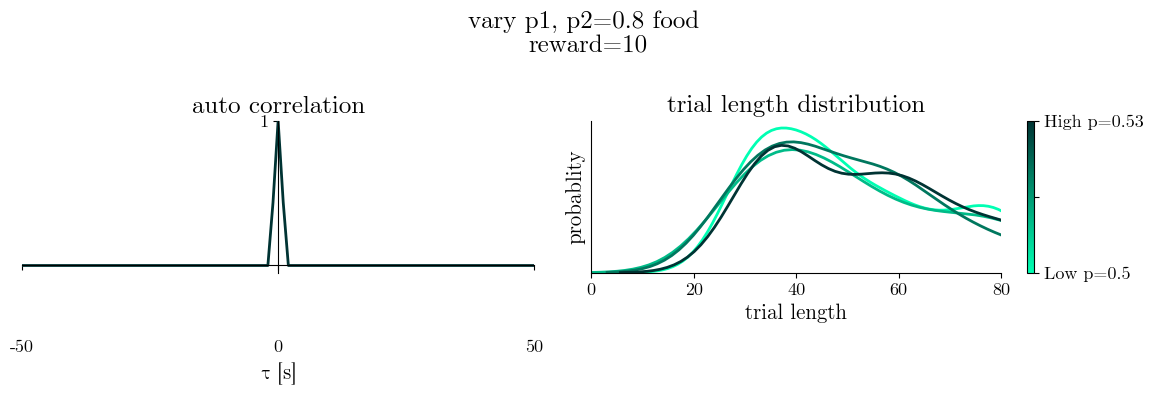

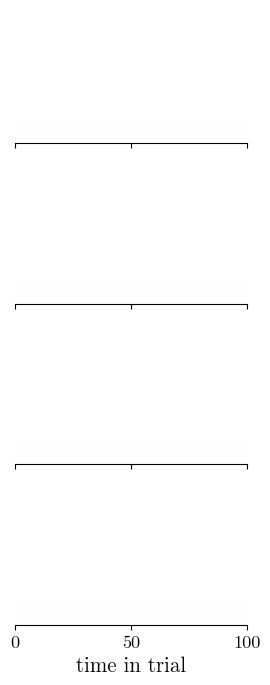

142 1 0
128 1 1
149 1 2
142 1 3


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_99066/2185044810.py:153: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


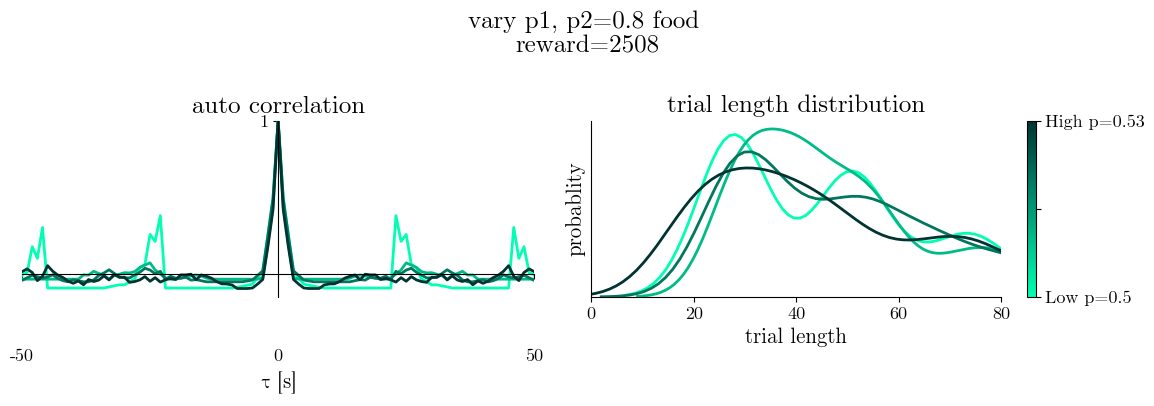

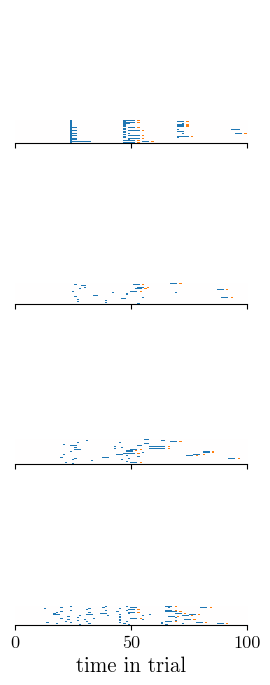

164 2 0
126 2 1
144 2 2
140 2 3


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_99066/2185044810.py:153: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


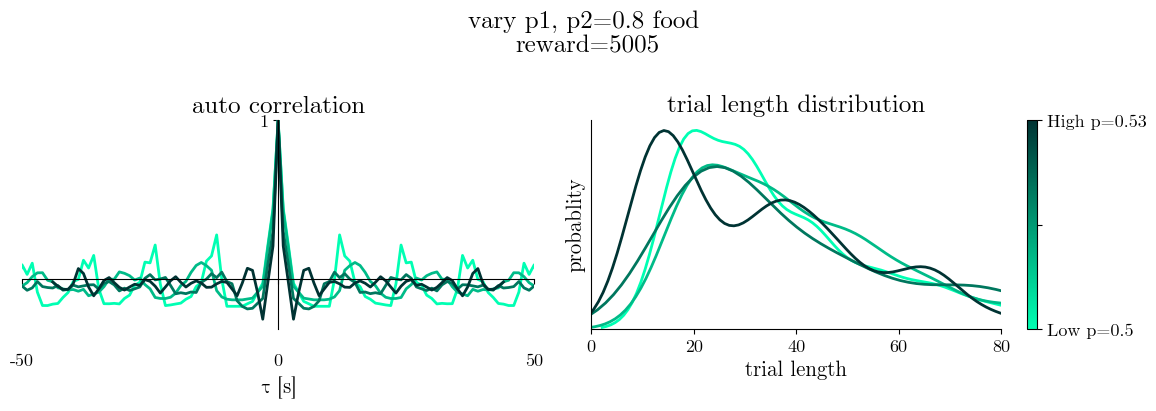

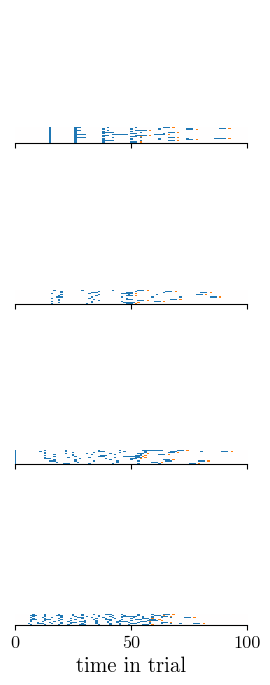

114 3 0
128 3 1
122 3 2
128 3 3


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_99066/2185044810.py:153: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


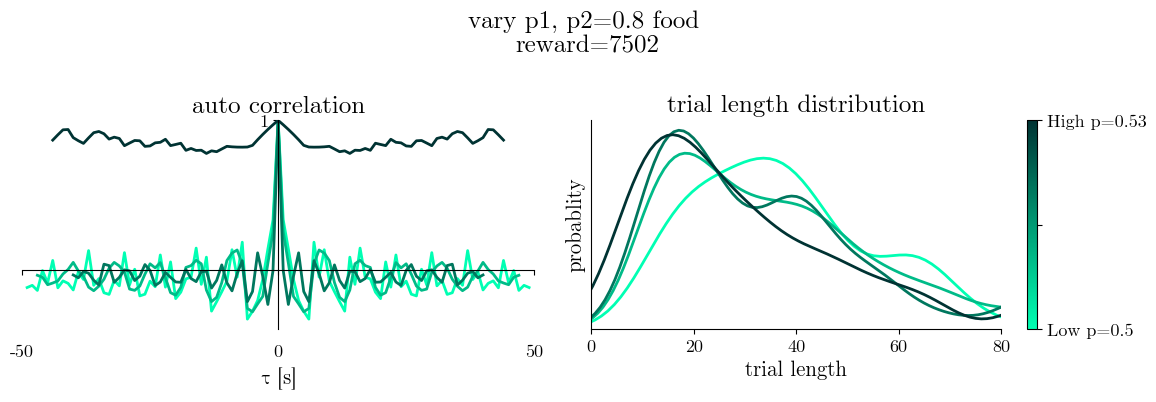

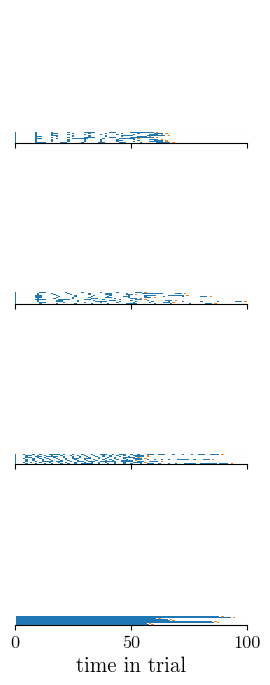

123 4 0
138 4 1
129 4 2
125 4 3


/Users/yc/repo/auditory-foraging-IRC/ult.py:1046: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1046: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_99066/2185044810.py:153: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


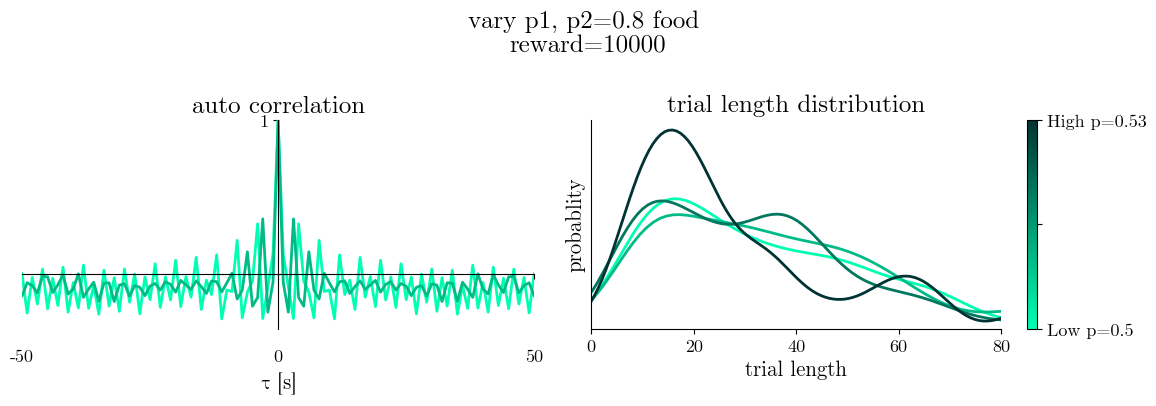

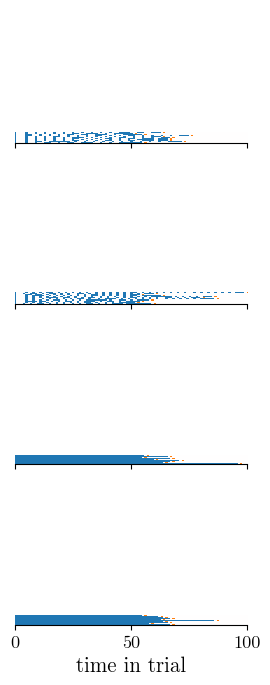

In [5]:
# old eval collection --------------------
res={}
for food_reward_idx in range(len(food_reward_list)):
    res[food_reward_idx]={}

for ip, p1p2 in enumerate(plist):
    thismodel = f'seed{seed}_{modelname}_p{ip}_ep{iepoch}'
    task = AFR2(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                'experiment':{                              'no_signal_nodes':node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    model = PPO.load(f'ycstore/{thismodel}', env=taskbelief)
    
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))
    
    for episode in all_episode_data:
        if ip in res[episode['trial_food_reward_idx']]:
            res[episode['trial_food_reward_idx']][ip].append(episode)
        else:
            res[episode['trial_food_reward_idx']][ip]=[episode]



In [ ]:

# eval ploting --------------------
for food_reward_idx in range(len(food_reward_list)):     

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    rasterfig, axs = plt.subplots(len(plist), 1, figsize=(
            3, len(plist)*2,), sharex=True, sharey=True)
    for ip, p1p2 in enumerate(plist):
        all_episode_data=res[food_reward_idx][ip]

        # att times -------------
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
        for episode in all_episode_data[:]:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))

        # raster fig
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
            food_reward_idx]
        trial_len = np.array(trial_len)
        valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
        grid = np.zeros((len(valid_ind), max(trial_len)+2))
        # print(food_reward_idx,ip, grid.shape)
        sortind = np.argsort([trial_len[i] for i in valid_ind])

        # att
        plot_data = [att_time_list[i] for i in valid_ind]
        for i, arr in enumerate(plot_data):
            grid[i, arr] = -1
        # lick
        plot_data = [lick_time_list[i] for i in valid_ind]
        for i, arr in enumerate(plot_data):
            if arr:
                grid[i, arr] = 1

        colors = [attn_color, 'white', lick_color]
        stops = [0.0, 0.5, 1.0]
        attnlickcmap = LinearSegmentedColormap.from_list(
            'custom_cmap', list(zip(stops, colors)))

        c = axs[ip].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                            aspect='auto', interpolation='none')

        axs[ip].set_xticks([0, 50, 100])
        axs[ip].set_xlim(0, 100)
        axs[ip].set_ylim(0,300)
        axs[ip].set_yticks([])
        axs[ip].spines['left'].set_visible(False)

        # auto correlation -------------
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        print(len(sequences), food_reward_idx, ip)
        autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,

                    label=f'p:{p1p2}', color=cmap(np.linspace(0, 1, len(plist)))[ip])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(plist)))[ip])


    axs[ip].set_xlabel('time in trial')
    # lickdot = Patch(color=lick_color, label='lick')
    # attdot = Patch(color=attn_color, label='attention')
    # extra_legend = plt.legend(
    #     handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
    # ax.add_artist(extra_legend)
    rasterfig.show()


    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
    ticks = [0, 0.5, 1]
    tick_labels = [f'Low p={plist[0][0]}', '', f'High p={plist[-1][0]}']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    fig.suptitle(f'vary p1, p2={p1p2[1]} food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.tight_layout()
    plt.show()


In [6]:
# new with df

res=[]
for ip, p1p2 in enumerate(plist):
    thismodel = f'seed{seed}_{modelname}_p{ip}_ep{iepoch}'
    task = AFR2(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                'experiment':{                              'no_signal_nodes':node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    model = PPO.load(f'ycstore/{thismodel}', env=taskbelief)
    
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))
    res+=all_episode_data
testres=res.copy()

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrap

In [7]:
for episode in testres:
    episode['ip']=np.where(plist==episode['p1p2'][0])[0].item()
    lick_time_list,att_time_list,trial_len=[],[],[]
    att=np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
    
    if np.sum(att)==0: 
        continue
    episode['att_time_list']=att
    if episode['actions'][-1][0] == 1:
        episode['lick_time']=int(len(episode['states']))
    else:
        episode['lick_time']=-1
    episode['trial_len']=len(episode['actions'])

df = pd.DataFrame(testres)
df=df[~df.att_time_list.isna()]
df=df[df.lick_time!=-1]
df.lick_time=df.lick_time.astype('int')
# df.head()

555 1 0
383 1 1
555 1 2
555 1 3
555 2 0
555 2 1


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


555 2 2
555 2 3
555 3 0
555 3 1
555 3 2
555 3 3
555 4 0


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


555 4 1
555 4 2
555 4 3


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/1762533113.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


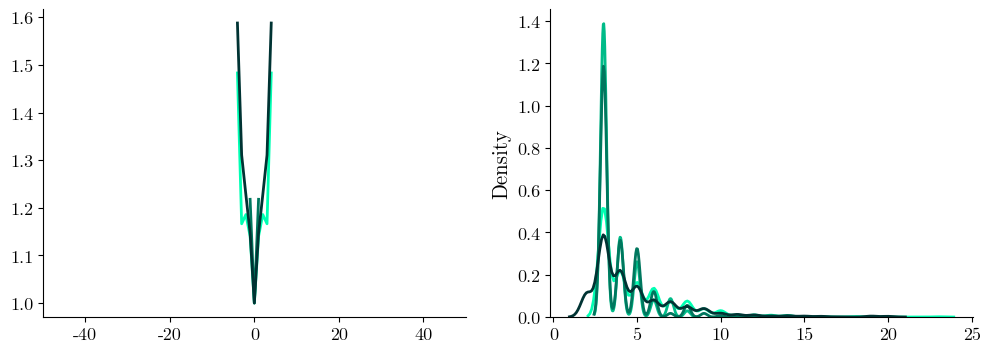

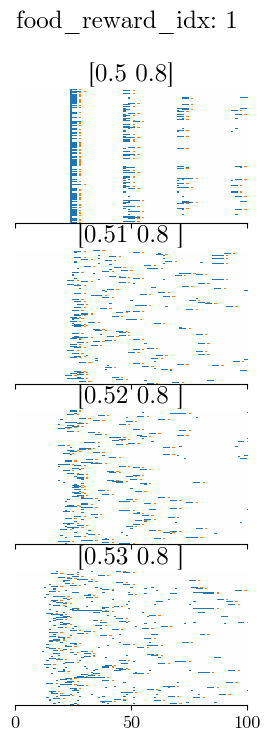

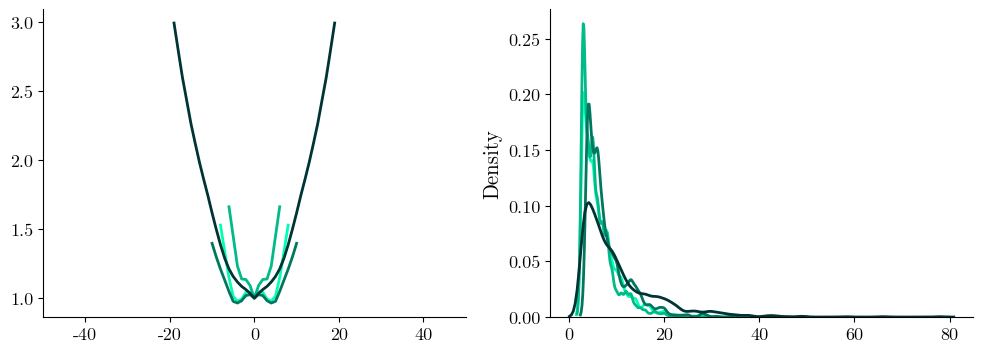

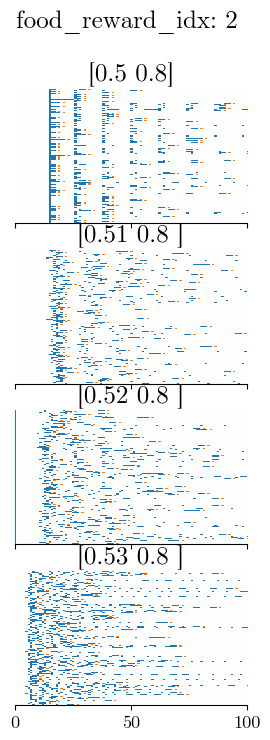

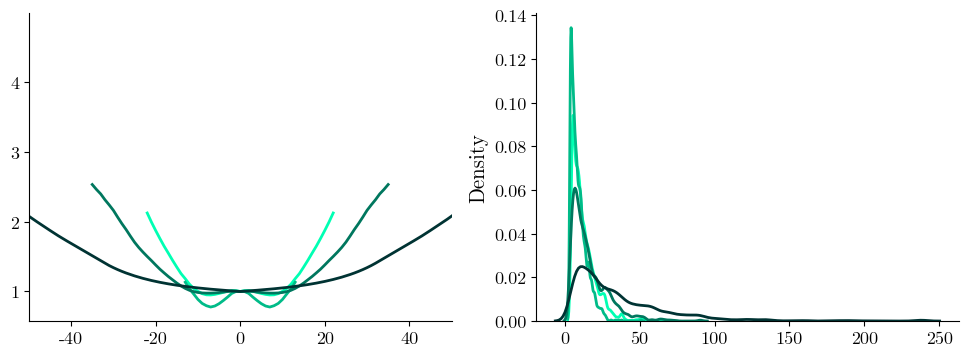

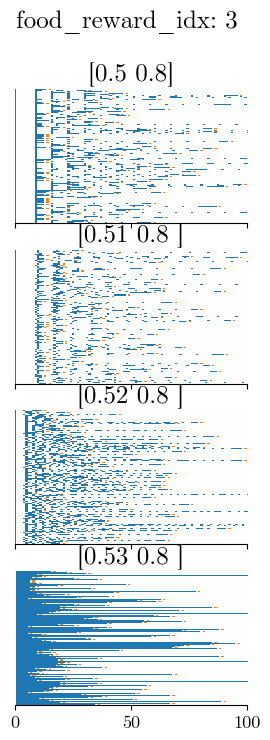

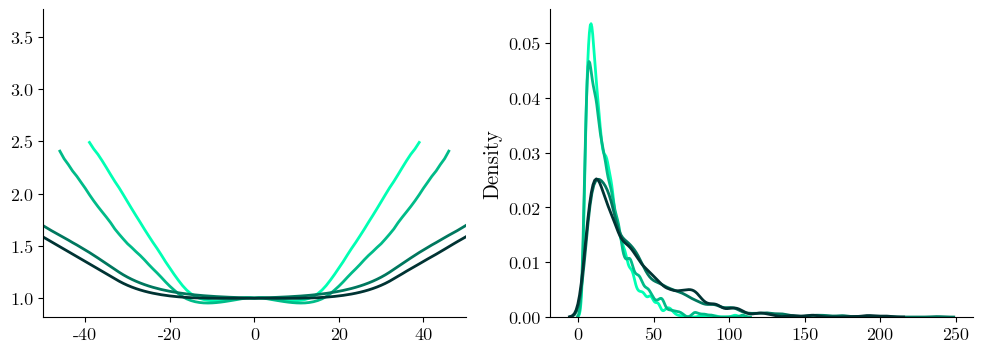

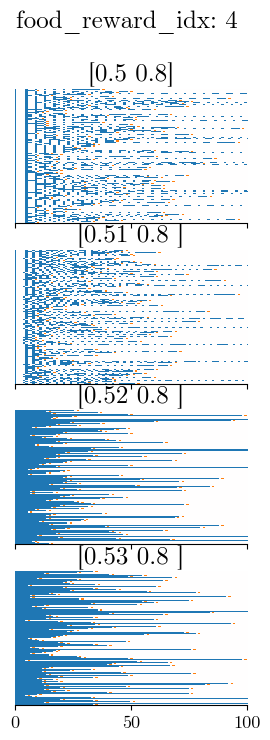

In [21]:
# new with df

for food_reward_idx in np.arange(len(food_reward_list))[1:]:     

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    rasterfig, axs = plt.subplots(len(plist), 1, figsize=(
            3, len(plist)*2,), sharex=True, sharey=True)
    
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)&((df.trial_len>minlen)|(df.trial_len<maxlen))]
        if len(subdf)==0: continue
        # raster plot ----------------
        grid = np.zeros((len(subdf),999))
        sortind=np.argsort(subdf.trial_len)

        # att
        plot_data = np.array(subdf.att_time_list)
        for i, arr in enumerate(plot_data):
            grid[i, arr] = -1
        # lick
        plot_data = np.array(subdf.lick_time)
        for i, arr in enumerate(plot_data):
            if arr:
                grid[i, arr] = 1

        colors = [attn_color, 'white', lick_color]
        stops = [0.0, 0.5, 1.0]
        attnlickcmap = LinearSegmentedColormap.from_list(
            'custom_cmap', list(zip(stops, colors)))

        c = axs[ip].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                            aspect='auto', interpolation='none')

        axs[ip].set_xticks([0, 50, 100])
        axs[ip].set_xlim(0, 100)
        axs[ip].set_ylim(0,300)
        axs[ip].set_yticks([])
        axs[ip].spines['left'].set_visible(False)
        axs[ip].set_title(f'{p1p2}')

        # auto correlation -------------
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)]
        att_seq_list = np.array(subdf.att_time_list)
        sortind=np.argsort(subdf.trial_len)
        sequences = att_seq_list[sortind][-plot_no_episodes:]
        # autocorr
        print(len(sequences), food_reward_idx, ip)
        autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                    label=f'p:{p1p2}', color=cmap(np.linspace(0, 1, len(plist)))[ip])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(plist)))[ip])
        
    # ax1.set_xlabel(r'$\tau$ [s]')
    # ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    # ax1.set_ylim(None, 1)
    # ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    # ax1.set_yticks([1])
    # ax1.spines['left'].set_position('zero')
    # ax1.spines['bottom'].set_position('zero')
    # ax1.tick_params(axis='x', pad=50) 

    # ax2.set_xlabel('trial length')
    # ax2.set_ylabel('probablity')
    # ax2.set_yticks([])
    # ax2.set_xlim(0, 80)
    # ax2.set_title('trial length distribution')

    # color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
    # ticks = [0, 0.5, 1]
    # tick_labels = [f'Low p={plist[0][0]}', '', f'High p={plist[-1][0]}']
    # color_bar.set_ticks(ticks)
    # color_bar.set_ticklabels(tick_labels)


    fig.show()
    rasterfig.suptitle(f'food_reward_idx: {food_reward_idx}')
    rasterfig.show()

In [34]:
subdf=df[(df.trial_food_reward_idx==4) &(df.ip==0)]
att_seq_list = np.array(subdf.att_time_list)
sortind=np.argsort(subdf.trial_len)
att_seq_list, 
att_seq_list[sortind]
len(att_seq_list)
autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
xs = np.arange(0, len(autocorr), 11)
xs = xs-len(xs)//2
# ax1.plot(xs, autocorr,
#             label=f'p:{p1p2}', color=cmap(np.linspace(0, 1, len(plist)))[ip])
# # trial len dist
# sns.kdeplot([len(a) for a in att_seq_list],
#             fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(plist)))[ip])

# plt.plot(autocorr)
autocorr


array([3.63051002, 3.61739698, 3.6042627 , 3.59120071, 3.55865735,
       3.52816559, 3.49602754, 3.46612152, 3.43167392, 3.38715583,
       3.34644935, 3.30926228, 3.2781172 , 3.24970275, 3.22124486,
       3.19291073, 3.15771219, 3.11907352, 3.07554736, 3.03433317,
       2.98941471, 2.94916871, 2.91315945, 2.87063671, 2.83269382,
       2.79416876, 2.75989128, 2.72368745, 2.68741866, 2.65130302,
       2.6092333 , 2.56236297, 2.51742681, 2.47116558, 2.42306224,
       2.37568233, 2.3264506 , 2.28039074, 2.23563057, 2.18908887,
       2.1473751 , 2.10641522, 2.0629486 , 2.02281956, 1.98575505,
       1.95033407, 1.9176324 , 1.88582637, 1.85495685, 1.82163916,
       1.79059834, 1.76211045, 1.73595517, 1.71193328, 1.68673078,
       1.66136994, 1.63490693, 1.6096733 , 1.58528027, 1.56171552,
       1.53926606, 1.51554125, 1.49163809, 1.46713585, 1.44297653,
       1.41944966, 1.39655564, 1.37406356, 1.35112569, 1.32704079,
       1.30363857, 1.2805211 , 1.25753876, 1.23297742, 1.20898

In [203]:
subdf

,trial_food_reward_idx,num_steps,actions,rewards,states,observations,beliefs,p1p2,q_states,q_probs,ip,att_time_list,lick_time,trial_len
7642,0,45,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [0], [0], [1], [1], [0], [1], [1], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.53, 0.8]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,"[43, 44]",46,45.0
7656,0,67,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [0], [1], [1], [0], [1], [1], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.53, 0.8]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,"[65, 66]",68,67.0
7728,0,112,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [0], [1], [1], [0], [1], [0], [0], [0], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.53, 0.8]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,"[110, 111]",113,112.0
7993,0,32,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [0], [0], [0], [0], [1], [1], [0], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.53, 0.8]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,"[30, 31]",33,32.0
8255,0,32,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [0], [0], [0], [0], [1], [1], [0], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.53, 0.8]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,"[30, 31]",33,32.0


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_69251/2299565436.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in subdf.att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=varypcmap(
webf NOT subset; don't know how to subset; dropped


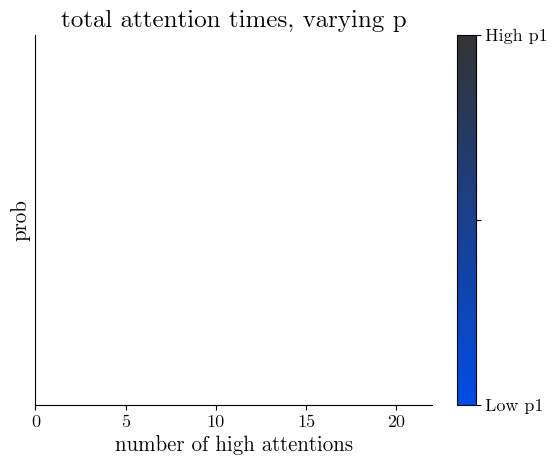

webf NOT subset; don't know how to subset; dropped


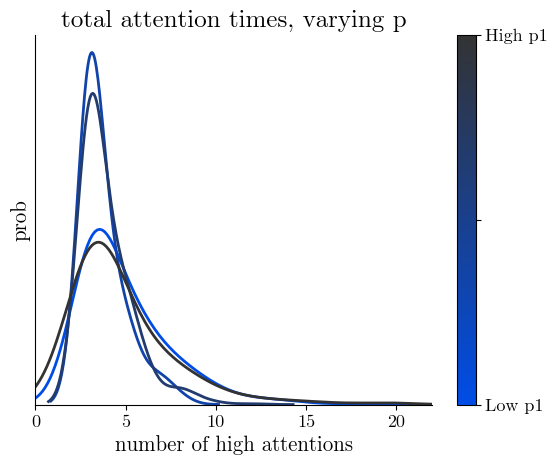

webf NOT subset; don't know how to subset; dropped


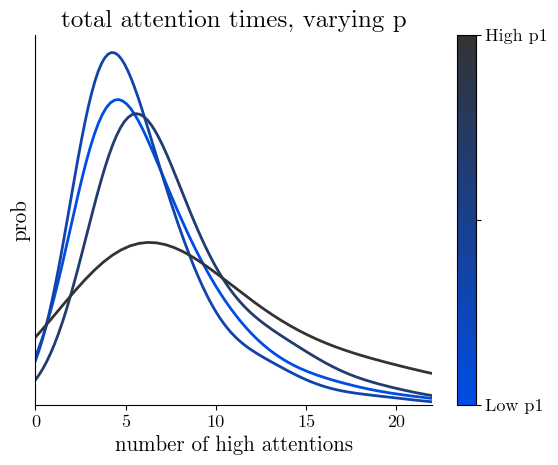

webf NOT subset; don't know how to subset; dropped


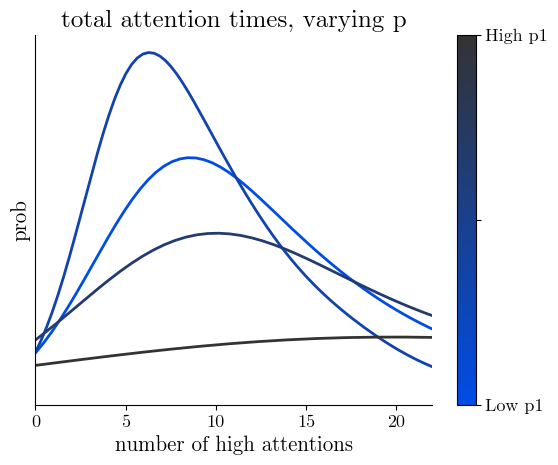

webf NOT subset; don't know how to subset; dropped


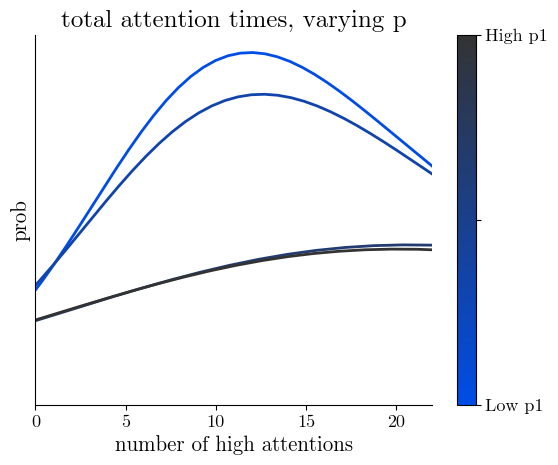

In [55]:
# total attn time

start_rgb = (0.0, 0.3, 0.9) # low reward
end_rgb = (0.2, 0.2, 0.2) # high reward
varypcmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])

for food_reward_idx in np.arange(len(food_reward_list)):
    fig= plt.figure()
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)]
        sns.kdeplot([len(a) for a in subdf.att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=varypcmap(
            np.linspace(0, 1, len(plist)))[ip])


    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=varypcmap), ax=plt.gca())
    ticks = [0, 0.5, 1]
    tick_labels = ['Low p1', '', 'High p1']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    plt.xlabel('number of high attentions')
    plt.ylabel('prob')
    plt.title(f'total attention times, varying p')
    # plt.ylim(0,1500)
    # plt.legend()

    centerax(plt.gca())
    plt.yticks([])
    plt.xlim(0, 22)
    # plt.xticks([0, 15])
    quicksave('total att time', 'plot sigmoid', fig=fig)
    plt.show()

In [ ]:
# old eval collection --------------------
res={}
for food_reward_idx in range(len(food_reward_list)):
    res[food_reward_idx]={}
    
for ip, p1p2 in enumerate(plist):
    thismodel = f'seed{seed}_{modelname}_p{ip}_ep{iepoch}'
    task = AFR2(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                'experiment':{                              'no_signal_nodes':node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    model = PPO.load(f'ycstore/{thismodel}', env=taskbelief)
    
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))
    
    for episode in all_episode_data:
        if ip in res[episode['trial_food_reward_idx']]:
            res[episode['trial_food_reward_idx']][ip].append(episode)
        else:
            res[episode['trial_food_reward_idx']][ip]=[episode]




    sns.kdeplot([len(a) for a in att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=2, common_norm=False, color=cmap(
        np.linspace(0, 1, len(all_reward_res)))[food_reward_idx])


color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)


plt.xlabel('number of high attentions')
plt.ylabel('prob')
plt.title(f'total attention times, varying food reward')
# plt.ylim(0,1500)

centerax(plt.gca())
plt.yticks([])
plt.xlim(0, 40)
plt.xticks([0, 20, 40])
# plt.legend()
plt.show()



# eval ploting --------------------
for food_reward_idx in range(len(food_reward_list)):     

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    
    for ip, p1p2 in enumerate(plist):
        all_episode_data=res[food_reward_idx][ip]

        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
        
        sns.kdeplot([len(a) for a in subdf.att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=varypcmap(
            np.linspace(0, 1, len(plist)))[ip])


    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=varypcmap), ax=plt.gca())
    ticks = [0, 0.5, 1]
    tick_labels = ['Low p1', '', 'High p1']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    plt.xlabel('number of high attentions')
    plt.ylabel('prob')
    plt.title(f'total attention times, varying p')
    # plt.ylim(0,1500)
    # plt.legend()

    centerax(plt.gca())
    plt.yticks([])
    plt.xlim(0, 22)
    # plt.xticks([0, 15])
    quicksave('total att time', 'plot sigmoid', fig=fig)
    plt.show()


# use figdata

In [89]:

res=open_pickle_file('figdata/vary node p.pkl')

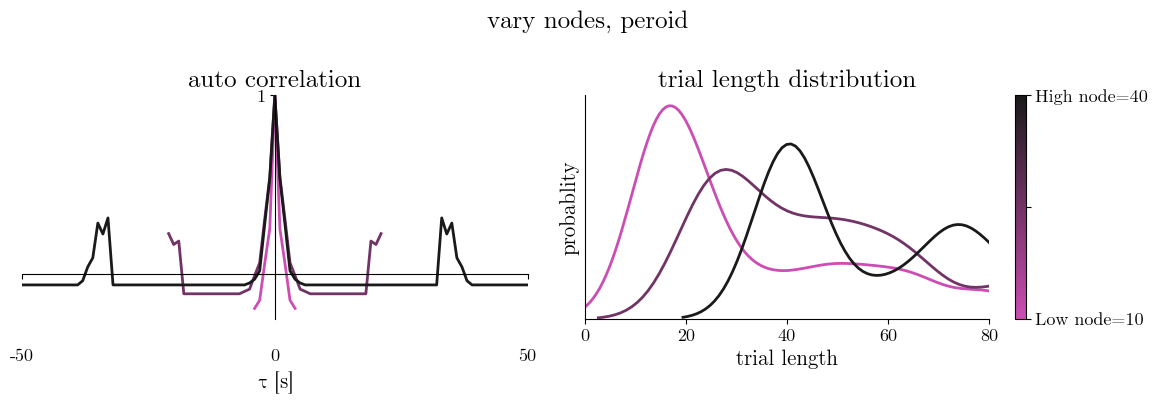

In [101]:
for food_reward_idx in [1]:        
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

    for inode, node in enumerate(node_list):
        all_episode_data=res[food_reward_idx][inode]
        
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                    label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[inode])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[inode])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
    ticks = [0, 0.5, 1]
    tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.suptitle(f'vary nodes, peroid')
    plt.tight_layout()
    plt.show()

(391, 194)
(533, 296)
(628, 344)


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_5857/102630010.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_5857/102630010.py:122: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
webf NOT subset; don't know how to subset; dropped


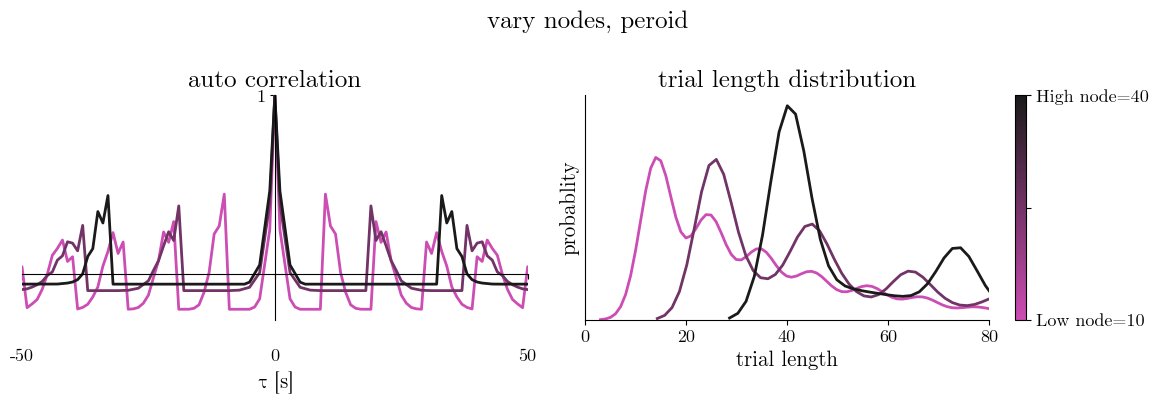

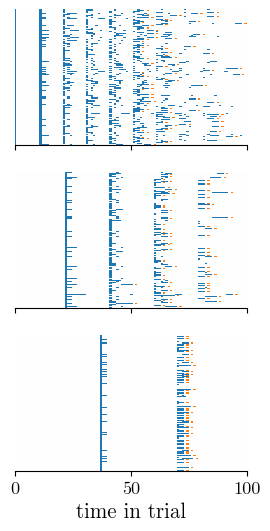

In [107]:
# autocorr with raster
start_rgb = (0.8, 0.3, 0.7) # low node
end_rgb = (0.1, 0.1, 0.1) # high node
cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])

minlen, maxlen=50,100
for food_reward_idx in [1]:        
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    rasterfig, axs = plt.subplots(len(node_list), 1, figsize=(
            3, len(node_list)*2,), sharex=True, sharey=True)
    for inode, node in enumerate(node_list):
        all_episode_data=res[food_reward_idx][inode]

        # att times -------------
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
        for episode in all_episode_data[:]:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))


        # raster fig
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
            food_reward_idx]
        trial_len = np.array(trial_len)
        valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
        grid = np.zeros((len(valid_ind), max(trial_len)+2))
        print(grid.shape)
        sortind = np.argsort([trial_len[i] for i in valid_ind])

        # att
        plot_data = [att_time_list[i] for i in valid_ind]
        for i, arr in enumerate(plot_data):
            grid[i, arr] = -1
        # lick
        plot_data = [lick_time_list[i] for i in valid_ind]
        for i, arr in enumerate(plot_data):
            if arr:
                grid[i, arr] = 1

        colors = [attn_color, 'white', lick_color]
        stops = [0.0, 0.5, 1.0]
        attnlickcmap = LinearSegmentedColormap.from_list(
            'custom_cmap', list(zip(stops, colors)))

        c = axs[inode].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                            aspect='auto', interpolation='none')

        axs[inode].set_xticks([0, 50, 100])
        axs[inode].set_xlim(0, 100)
        axs[inode].set_ylim(0,300)
        axs[inode].set_yticks([])
        axs[inode].spines['left'].set_visible(False)

        # auto correlation -------------
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,

                    label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[inode])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[inode])


    axs[inode].set_xlabel('time in trial')
    # lickdot = Patch(color=lick_color, label='lick')
    # attdot = Patch(color=attn_color, label='attention')
    # extra_legend = plt.legend(
    #     handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
    # ax.add_artist(extra_legend)
    rasterfig.show()


    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
    ticks = [0, 0.5, 1]
    tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.suptitle(f'vary nodes, peroid')
    fig.tight_layout()
    fig.show()
    


quicksave('autocorr p', 'plot vary node', fig=fig)
rasterfig.savefig('fig/plot vary node/autocorr raster p.svg')


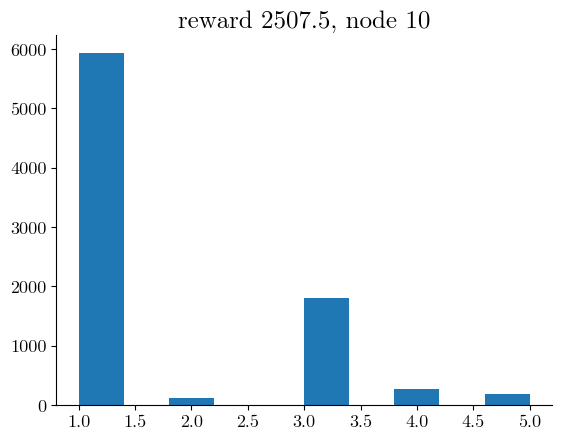

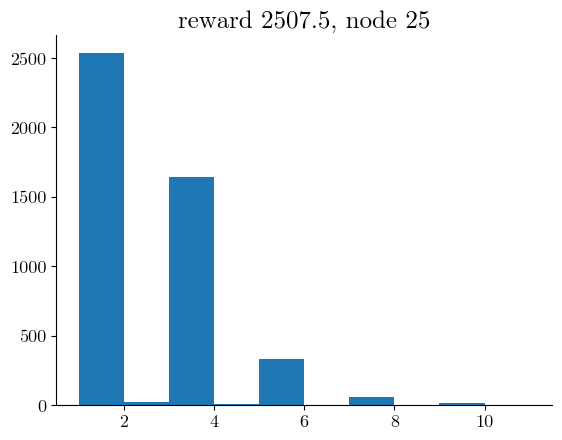

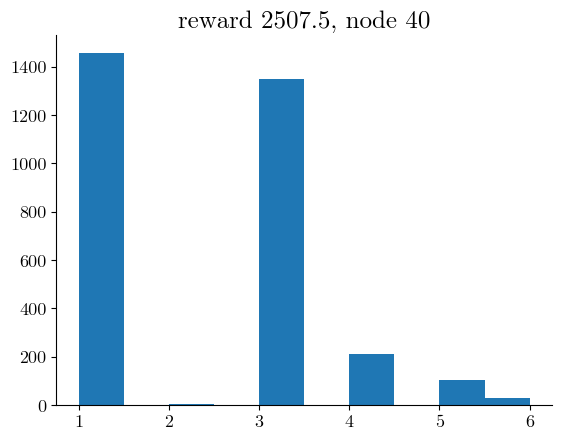

In [125]:
# continous att block distribution
# find_block_lengths()
for food_reward_idx in [1]:        
    for inode, node in enumerate(node_list):
        all_episode_data=res[food_reward_idx][inode]
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
        for episode in all_episode_data[:]:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))
        plt.hist(np.concatenate([find_block_lengths(a) for a in att_time_list]))
        plt.title(f'reward {food_reward_list[food_reward_idx]}, node {node_list[inode]}')
        plt.show()
  

# extra

In [55]:

# modelname = 'varynode'
# iepoch=51
# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 3333  # for eval plot during training
# plot_no_episodes = 333
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)
# node_list = [10, 25, 40]


# # for food_reward_idx in range(len(food_reward_list)):
# for food_reward_idx in [1]:
#         fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
        
#         # autocorr. 
#         for i, node in enumerate(node_list):
#             env_param = [0, None, attcost, .25, facost, 0, 0]
#             seed=0
#             thismodel = f'seed_0_{modelname}_{node}'
#             np.random.seed(seed)
#             task = AFR2(spec={'agent': 
#                                                 {'lick_cost': env_param[0],
#                                                 'food_reward': env_param[1],
#                                                 'attention_cost_coeff': env_param[2],
#                                                 'attention_cost_temp': env_param[3],
#                                                 'penalty_cost': env_param[4],
#                                                 'iti_cost': env_param[5],
#                                                 'time_in_game_reward': env_param[6]},
#                                         'experiment':{                              'no_signal_nodes':node}})
#             task.food_reward_list = food_reward_list
#             taskbelief = FuncBeliefModel(env=task, rng=1)
#             task.obs_certainity_possible = np.array([.5,.7])
    
#             # eval
#             model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#             print(f'ycstore/{thismodel}_epoch_{iepoch}')
            
#             def eval_wrapper(a):
#                 episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                         num_steps=100000, deterministic=True)
#                 return episode

#             with multiprocess.Pool(processes=8) as pool:
#                 all_episode_data = pool.map(eval_wrapper, range(no_episodes))

#             # auto correlation
#             att_seq_list = []
#             for episode in all_episode_data:
#                 if 

In [ ]:
episode['trial_food_reward_idx'] == food_reward_idx:
#                     att_seq_list.append([float(elt[1])
#                                         for elt in episode['actions']])
#             # Sorting based on increasing trial length
#             sorted_list_of_lists = sorted(att_seq_list, key=len)
#             # Choosing what range of trial lengths to use. Could modify to be more consistent.
#             sequences = sorted_list_of_lists[-plot_no_episodes:]
#             # autocorr
#             autocorr, total_counts = empirical_autocorrelation(
#                 sequences, min_no_samples=1111)
#             xs = np.arange(0, len(autocorr), 1)
#             xs = xs-len(xs)//2
#             ax1.plot(xs, autocorr,
#                         label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[i])
#             # trial len dist
#             sns.kdeplot([len(a) for a in att_seq_list],
#                         fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[i])

#         ax1.set_xlabel(r'$\tau$ [s]')
#         ax1.set_title('auto correlation')
#         ax1.set_xlim(-50,50)
#         ax1.set_xticks([-50, 0, 50])
#         ax1.set_yscale('log')
#         ax1.set_yticks([])
#         ax1.spines['left'].set_position('zero')

#         ax2.set_xlabel('trial length')
#         ax2.set_ylabel('probablity')
#         ax2.set_yticks([])
#         ax2.set_xlim(0, 80)
#         ax2.set_title('trial length distribution')

#         color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
#         ticks = [0, 0.5, 1]
#         tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
#         color_bar.set_ticks(ticks)
#         color_bar.set_ticklabels(tick_labels)


#         # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
#         fig.suptitle(f'vary nodes, peroid')
#         plt.tight_layout()
#         plt.show()

In [56]:
# from ult import empirical_autocorrelation_new
# modelname = 'varynode'
# iepoch=51
# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 9999  # for eval plot during training
# plot_no_episodes = 333
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)
# node_list = [10, 25, 40]


# # for food_reward_idx in range(len(food_reward_list)):
# for food_reward_idx in [1]:
#         fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
        
#         # autocorr. 
#         for i, node in enumerate(node_list):
#             env_param = [0, None, attcost, .25, facost, 0, 0]
#             seed=0
#             thismodel = f'seed_0_{modelname}_{node}'
#             np.random.seed(seed)
#             task = AFR2(spec={'agent': 
#                                                 {'lick_cost': env_param[0],
#                                                 'food_reward': env_param[1],
#                                                 'attention_cost_coeff': env_param[2],
#                                                 'attention_cost_temp': env_param[3],
#                                                 'penalty_cost': env_param[4],
#                                                 'iti_cost': env_param[5],
#                                                 'time_in_game_reward': env_param[6]},
#                                         'experiment':{                              'no_signal_nodes':node}})
#             task.food_reward_list = food_reward_list
#             taskbelief = FuncBeliefModel(env=task, rng=1)
#             task.obs_certainity_possible = np.array([.5,.7])
    
#             # eval
#             model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#             print(f'ycstore/{thismodel}_epoch_{iepoch}')
            
#             def eval_wrapper(a):
#                 episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                         num_steps=100000, deterministic=True)
#                 return episode

#             with multiprocess.Pool(processes=8) as pool:
#                 all_episode_data = pool.map(eval_wrapper, range(no_episodes))

#             # auto correlation
#             att_seq_list = []
#             for episode in all_episode_data:
#                 if episode['trial_food_reward_idx'] == food_reward_idx:
#                     att_seq_list.append([float(elt[1])
#                                         for elt in episode['actions']])
#             # Sorting based on increasing trial length
#             sorted_list_of_lists = sorted(att_seq_list, key=len)
#             # Choosing what range of trial lengths to use. Could modify to be more consistent.
#             sequences = sorted_list_of_lists[-plot_no_episodes:]
#             # autocorr
#             autocorr, total_counts = empirical_autocorrelation_new(
#                 sequences, min_no_samples=1111)
#             xs = np.arange(0, len(autocorr), 1)
#             xs = xs-len(xs)//2
#             ax1.plot(xs, autocorr,
#                         label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[i])
#             # trial len dist
#             sns.kdeplot([len(a) for a in att_seq_list],
#                         fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[i])

#         ax1.set_xlabel(r'$\tau$ [s]')
#         ax1.set_title('auto correlation')
#         ax1.set_xlim(-50, 50)
#         ax1.set_ylim(None, 1)
#         ax1.set_xticks([-50, 0, 50])
#         # ax1.set_yscale('log')
#         ax1.set_yticks([1])
#         ax1.spines['left'].set_position('zero')
#         ax1.spines['bottom'].set_position('zero')
#         ax1.tick_params(axis='x', pad=50) 

#         ax2.set_xlabel('trial length')
#         ax2.set_ylabel('probablity')
#         ax2.set_yticks([])
#         ax2.set_xlim(0, 80)
#         ax2.set_title('trial length distribution')

#         color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
#         ticks = [0, 0.5, 1]
#         tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
#         color_bar.set_ticks(ticks)
#         color_bar.set_ticklabels(tick_labels)


#         # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
#         fig.suptitle(f'vary nodes, peroid')
#         plt.tight_layout()
#         plt.show()

In [57]:


# modelname = 'varynode'
# iepoch=51
# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 999  # for eval plot during training
# plot_no_episodes =999
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)
# node_list = [10, 25, 40]
# minlen, maxlen = 50, 100

# # for food_reward_idx in range(len(food_reward_list)):
# for food_reward_idx in [1]:
#     fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
#     rasterfig, axs = plt.subplots(len(node_list), 1, figsize=(
#             2, len(node_list)*4,), sharex=True, sharey=True)
    
#     for nodei, node in enumerate(node_list):
#         env_param = [0, None, attcost, .25, facost, 0, 0]
#         seed=0
#         thismodel = f'seed_0_{modelname}_{node}'
#         np.random.seed(seed)
#         task = AFR2(spec={'agent': 
#                                             {'lick_cost': env_param[0],
#                                             'food_reward': env_param[1],
#                                             'attention_cost_coeff': env_param[2],
#                                             'attention_cost_temp': env_param[3],
#                                             'penalty_cost': env_param[4],
#                                             'iti_cost': env_param[5],
#                                             'time_in_game_reward': env_param[6]},
#                                     'experiment':{                              'no_signal_nodes':node}})
#         task.food_reward_list = food_reward_list
#         taskbelief = FuncBeliefModel(env=task, rng=1)
#         task.obs_certainity_possible = np.array([.5,.7])

#         # eval
#         model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#         print(f'ycstore/{thismodel}_epoch_{iepoch}')
        
#         def eval_wrapper(a):
#             episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                     num_steps=100000, deterministic=True)
#             return episode

#         with multiprocess.Pool(processes=8) as pool:
#             all_episode_data = pool.map(eval_wrapper, range(no_episodes))

#         # att times -------------
#         all_reward_res={} # k: v = foodreward idx: this food reward res
#         for r in range(len(food_reward_list)):
#             attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
#             all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
#         for episode in all_episode_data[:]:
#             attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
#             att_time_list.append(
#                 np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
#             if episode['actions'][-1][0] == 1:
#                 lick_time_list.append(len(episode['states']))
#             else:
#                 lick_time_list.append(None)
#             trial_len.append(len(episode['actions']))

#         attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
#             food_reward_idx]
#         trial_len = np.array(trial_len)
#         valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
#         grid = np.zeros((len(valid_ind), max(trial_len)+2))
#         sortind = np.argsort([trial_len[i] for i in valid_ind])

#         # att
#         plot_data = [att_time_list[i] for i in valid_ind]
#         for i, arr in enumerate(plot_data):
#             grid[i, arr] = -1
#         # lick
#         plot_data = [lick_time_list[i] for i in valid_ind]
#         for i, arr in enumerate(plot_data):
#             if arr:
#                 grid[i, arr] = 1

#         colors = [attn_color, 'white', lick_color]
#         stops = [0.0, 0.5, 1.0]
#         attnlickcmap = LinearSegmentedColormap.from_list(
#             'custom_cmap', list(zip(stops, colors)))

#         c = axs[nodei].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
#                             aspect='auto', interpolation='none')

#         plt.xticks([0, 50, 100])
#         plt.xlim(0, 100)
#         plt.yticks([])
#         ax = axs[nodei]
#         ax.spines['left'].set_visible(False)

#         # auto correlation -------------
#         att_seq_list = []
#         for episode in all_episode_data:
#             if episode['trial_food_reward_idx'] == food_reward_idx:
#                 att_seq_list.append([float(elt[1])
#                                     for elt in episode['actions']])
#         # Sorting based on increasing trial length
#         sorted_list_of_lists = sorted(att_seq_list, key=len)
#         # Choosing what range of trial lengths to use. Could modify to be more consistent.
#         sequences = sorted_list_of_lists[-plot_no_episodes:]
#         # autocorr
#         autocorr, total_counts = empirical_autocorrelation_new(
#             sequences, min_no_samples=1111)
#         xs = np.arange(0, len(autocorr), 1)
#         xs = xs-len(xs)//2
#         ax1.plot(xs, autocorr,
#                     label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[nodei])
#         # trial len dist
#         sns.kdeplot([len(a) for a in att_seq_list],
#                     fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[nodei])


#     plt.xlabel('time in trial')
#     lickdot = Patch(color=lick_color, label='lick')
#     attdot = Patch(color=attn_color, label='attention')
#     extra_legend = plt.legend(
#         handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
#     ax.add_artist(extra_legend)
#     rasterfig.show()


#     ax1.set_xlabel(r'$\tau$ [s]')
#     ax1.set_title('auto correlation')
#     ax1.set_xlim(-50, 50)
#     ax1.set_ylim(None, 1)
#     ax1.set_xticks([-50, 0, 50])
#     # ax1.set_yscale('log')
#     ax1.set_yticks([1])
#     ax1.spines['left'].set_position('zero')
#     ax1.spines['bottom'].set_position('zero')
#     ax1.tick_params(axis='x', pad=50) 

#     ax2.set_xlabel('trial length')
#     ax2.set_ylabel('probablity')
#     ax2.set_yticks([])
#     ax2.set_xlim(0, 80)
#     ax2.set_title('trial length distribution')

#     # color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
#     # ticks = [0, 0.5, 1]
#     # tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
#     # color_bar.set_ticks(ticks)
#     # color_bar.set_ticklabels(tick_labels)


#     # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
#     fig.suptitle(f'vary nodes, peroid')
#     plt.tight_layout()
#     fig.show()
    

